# Customer Segmentation using Clustering

**Goal:** Segment mall customers into distinct groups based on their **Age**, **Annual Income**, and **Spending Score**, so that marketing and business strategies can be tailored to each group.

This notebook walks through the full clustering workflow:
1. Data loading & exploration (EDA)
2. Preprocessing (scaling)
3. Choosing the optimal number of clusters (Elbow method + Silhouette score)
4. Comparing multiple clustering algorithms: **K-Means**, **Hierarchical (Agglomerative)**, and **DBSCAN**
5. Selecting the best model and profiling the resulting customer segments
6. Business interpretation & recommendations


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Data

The dataset contains the following columns:
- **CustomerID**: unique identifier for each customer
- **Gender**: Male / Female
- **Age**: customer's age
- **Annual Income (k$)**: yearly income in thousands of dollars
- **Spending Score (1-100)**: a score assigned by the mall based on customer behavior and spending patterns

> If you're running this notebook yourself, make sure `Mall_Customers.csv` is in the same folder as this notebook (or update the path below).


In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Summary statistics:")
df.describe()


Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Summary statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df['Gender'].value_counts()


Gender
Female    112
Male       88
Name: count, dtype: int64

**Observation:** The dataset is clean — 200 rows, 5 columns, no missing values. Ages range from 18 to 70, annual income from 15k$ to 137k$, and spending score from 1 to 99. There are slightly more female customers (112) than male (88).

## 3. Exploratory Data Analysis (EDA)

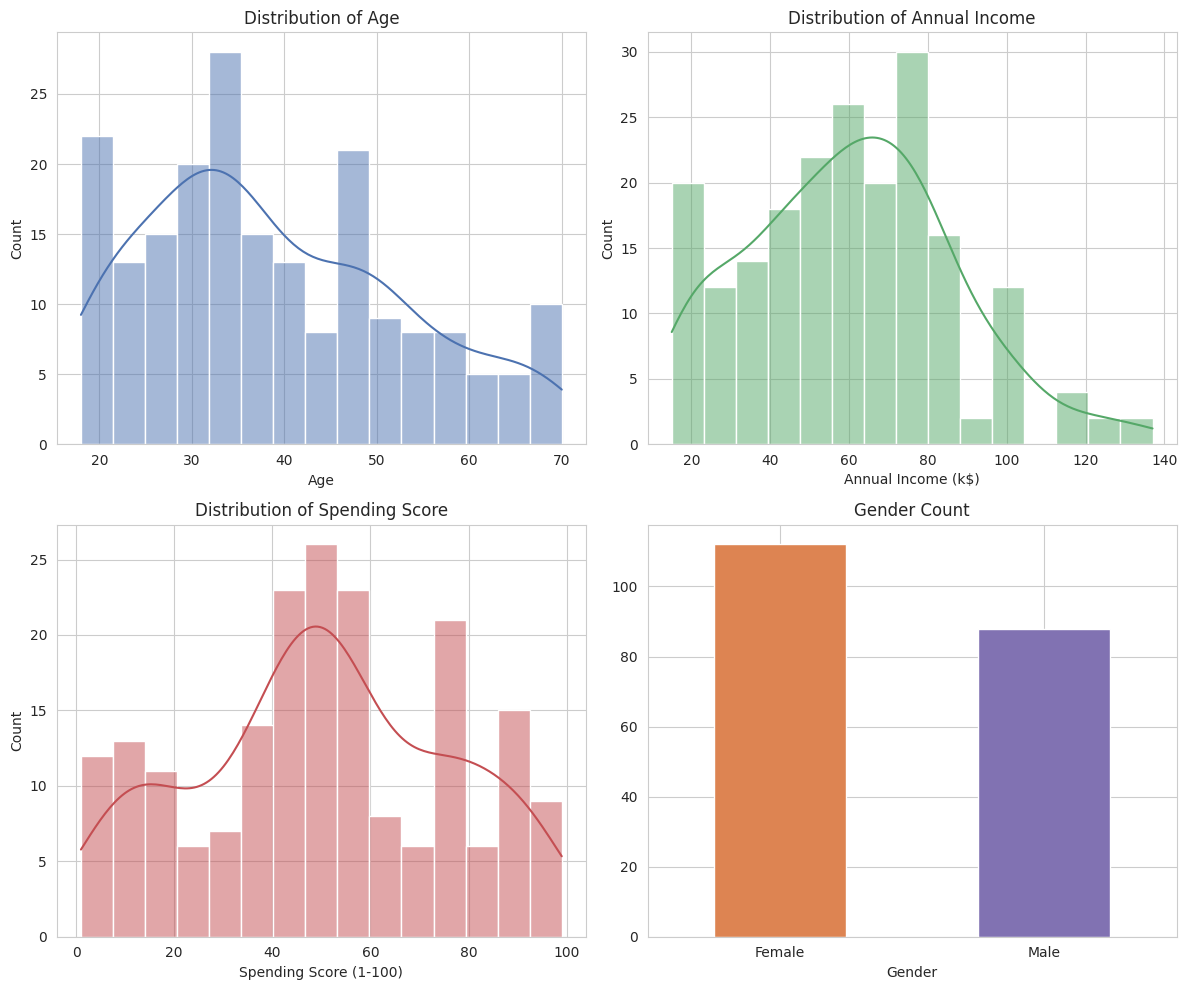

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df['Age'], bins=15, kde=True, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Distribution of Age')

sns.histplot(df['Annual Income (k$)'], bins=15, kde=True, ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Distribution of Annual Income')

sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True, ax=axes[1,0], color='#C44E52')
axes[1,0].set_title('Distribution of Spending Score')

df['Gender'].value_counts().plot(kind='bar', ax=axes[1,1], color=['#DD8452','#8172B2'])
axes[1,1].set_title('Gender Count')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


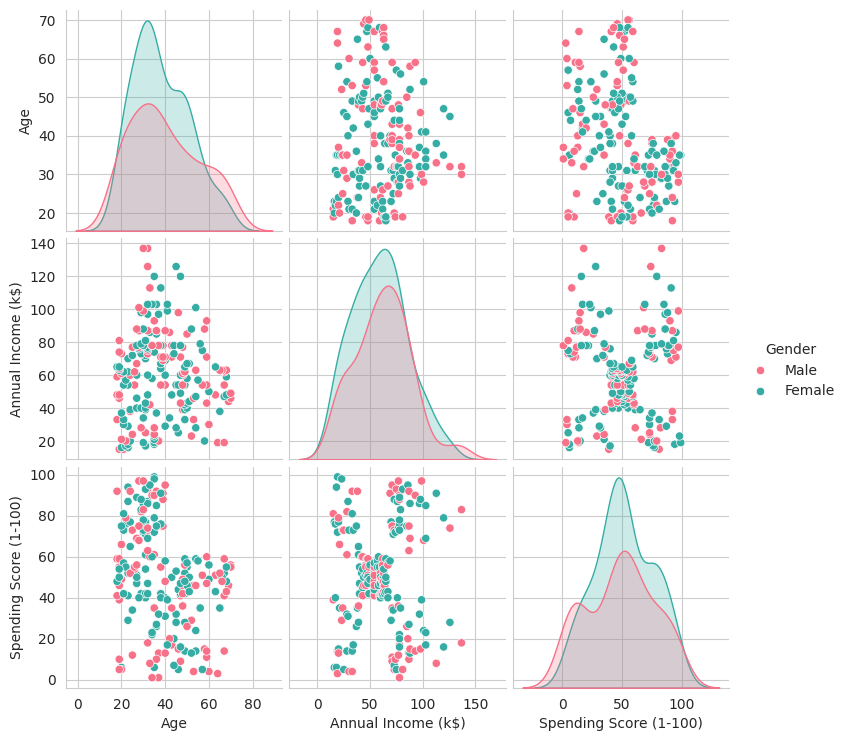

In [7]:
g = sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)','Gender']], hue='Gender', palette='husl')
plt.show()


**Observation:** There's no strong linear correlation between Age, Income, and Spending Score individually, but when we look at Income vs Spending Score together, distinct groupings become visible — this is a strong signal that clustering on these two features will be meaningful.

## 4. Preprocessing

We scale the numeric features with `StandardScaler` so that Income (scale of tens of thousands) doesn't dominate Spending Score (scale of 1-100) purely because of magnitude. This is essential for distance-based algorithms like K-Means, Hierarchical clustering, and DBSCAN.

We build two feature sets:
- **2D**: `Annual Income` + `Spending Score` (the classic, most interpretable segmentation)
- **3D**: `Age` + `Annual Income` + `Spending Score` (a richer segmentation)


In [8]:
X2 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)


## 5. Choosing the Optimal Number of Clusters

We use two complementary techniques:
- **Elbow Method**: plots Within-Cluster Sum of Squares (WCSS) vs. k — look for the "elbow" where adding more clusters stops giving big improvements.
- **Silhouette Score**: measures how well-separated and cohesive clusters are (ranges from -1 to 1, higher is better).


In [9]:
def elbow_silhouette(X, name):
    wcss = []
    sil = []
    K_range = range(2, 11)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        wcss.append(km.inertia_)
        sil.append(silhouette_score(X, labels))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(list(K_range), wcss, marker='o', color='#4C72B0')
    axes[0].set_title(f'Elbow Method ({name})')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('WCSS')

    axes[1].plot(list(K_range), sil, marker='o', color='#C44E52')
    axes[1].set_title(f'Silhouette Score ({name})')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')

    plt.tight_layout()
    plt.show()

    best_k = list(K_range)[int(np.argmax(sil))]
    print(f'{name}: best k by silhouette = {best_k}')
    for k, s in zip(K_range, sil):
        print(f'  k={k}: silhouette={s:.3f}')
    return best_k


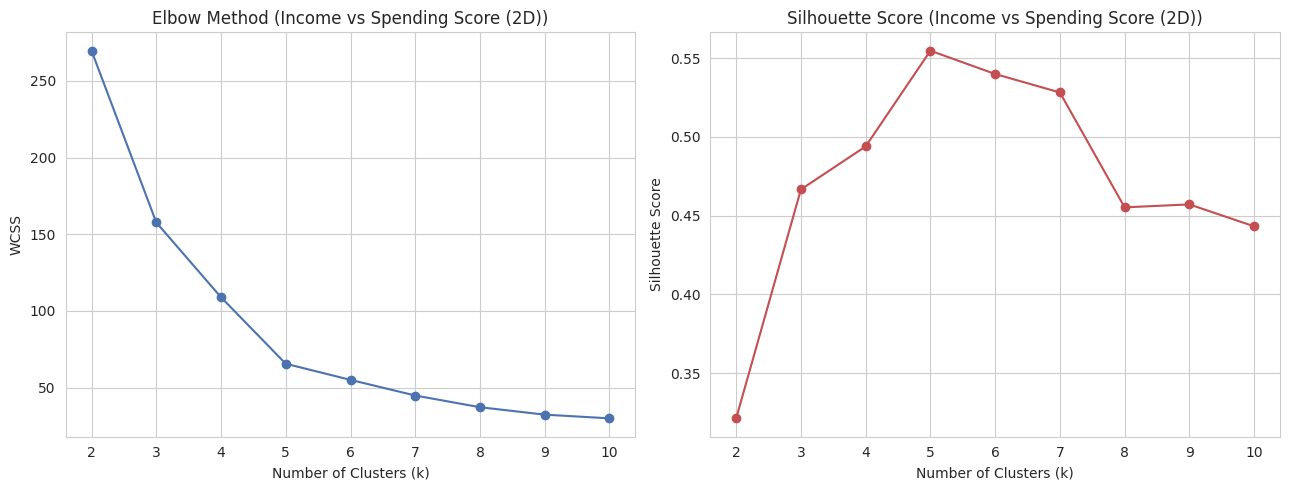

Income vs Spending Score (2D): best k by silhouette = 5
  k=2: silhouette=0.321
  k=3: silhouette=0.467
  k=4: silhouette=0.494
  k=5: silhouette=0.555
  k=6: silhouette=0.540
  k=7: silhouette=0.528
  k=8: silhouette=0.455
  k=9: silhouette=0.457
  k=10: silhouette=0.443


In [10]:
best_k_2d = elbow_silhouette(X2_scaled, 'Income vs Spending Score (2D)')


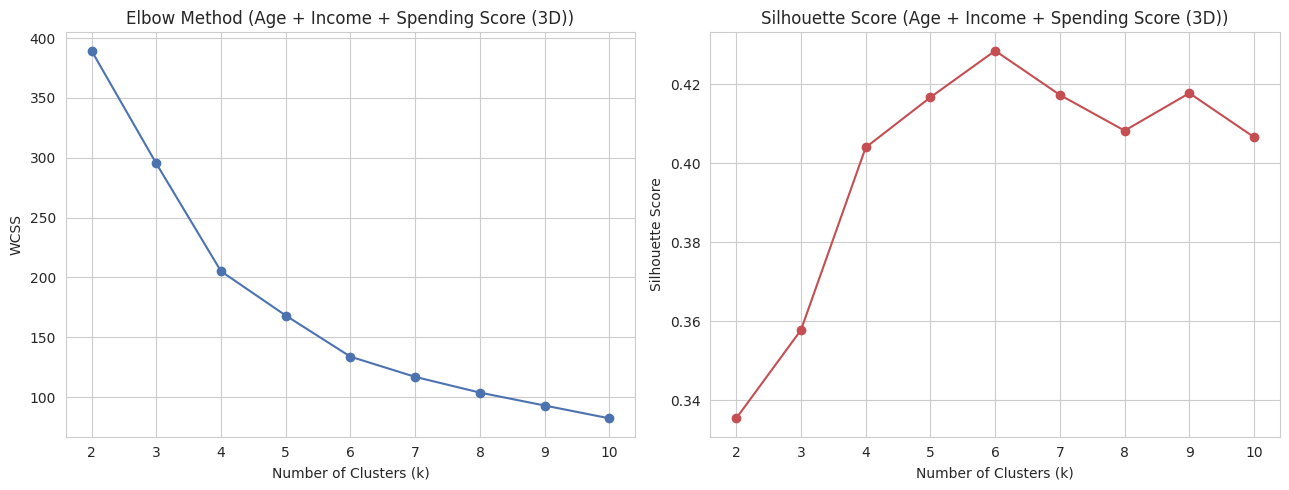

Age + Income + Spending Score (3D): best k by silhouette = 6
  k=2: silhouette=0.335
  k=3: silhouette=0.358
  k=4: silhouette=0.404
  k=5: silhouette=0.417
  k=6: silhouette=0.428
  k=7: silhouette=0.417
  k=8: silhouette=0.408
  k=9: silhouette=0.418
  k=10: silhouette=0.407


In [11]:
best_k_3d = elbow_silhouette(X3_scaled, 'Age + Income + Spending Score (3D)')


**Observation:** For the 2D feature set (Income vs Spending Score), both the elbow curve and the silhouette score clearly point to **k = 5** as the optimal number of clusters (silhouette ≈ 0.555 — the highest value in the range tested). This matches the well-known structure of this dataset. We'll proceed with **k=5** for our main analysis.

## 6. Comparing Clustering Algorithms

We now fit three different clustering algorithms on the 2D feature set (Income vs Spending Score) and compare them using the silhouette score:

1. **K-Means** — partitions data into k spherical clusters by minimizing within-cluster variance.
2. **Hierarchical / Agglomerative Clustering (Ward linkage)** — builds a tree of nested clusters; doesn't require choosing k upfront (visualized via a dendrogram) but we cut it at k=5 for a fair comparison.
3. **DBSCAN** — a density-based method that can find arbitrarily-shaped clusters and automatically flags outliers as noise (no need to specify k, but needs `eps` and `min_samples`).


### 6.1 Hierarchical Clustering — Dendrogram

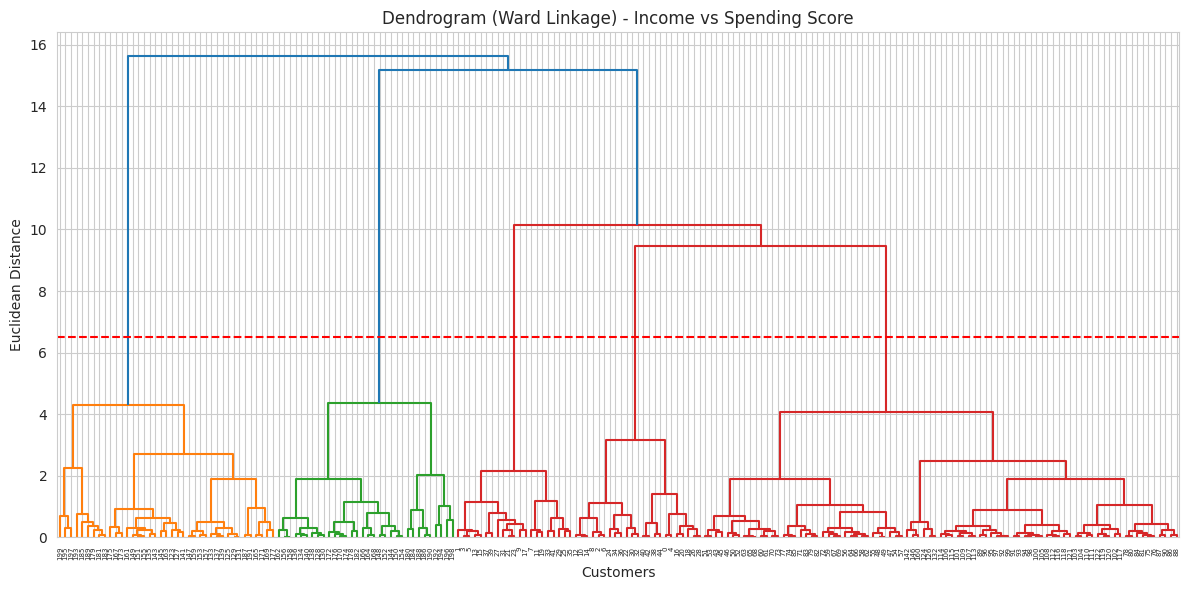

In [12]:
plt.figure(figsize=(12,6))
Z = linkage(X2_scaled, method='ward')
dendrogram(Z)
plt.title('Dendrogram (Ward Linkage) - Income vs Spending Score')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.axhline(y=6.5, color='r', linestyle='--')
plt.tight_layout()
plt.show()


**Observation:** Cutting the dendrogram at the red dashed line (distance ≈ 6.5) yields **5 clusters**, consistent with our earlier elbow/silhouette analysis.

### 6.2 Fit K-Means and Hierarchical Clustering (k=5)

In [13]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
km_labels = km.fit_predict(X2_scaled)
km_sil = silhouette_score(X2_scaled, km_labels)

agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X2_scaled)
agg_sil = silhouette_score(X2_scaled, agg_labels)

print(f'K-Means silhouette (k=5): {km_sil:.4f}')
print(f'Hierarchical silhouette (k=5): {agg_sil:.4f}')


K-Means silhouette (k=5): 0.5547
Hierarchical silhouette (k=5): 0.5538


### 6.3 DBSCAN — Finding the Right `eps`

DBSCAN needs an `eps` (neighborhood radius) parameter. We use the **k-distance graph** (distance to the 5th nearest neighbor, sorted) to find a good value — the "knee" of this curve is a good candidate for `eps`. We then search a small range around it and keep the value with the best silhouette score.


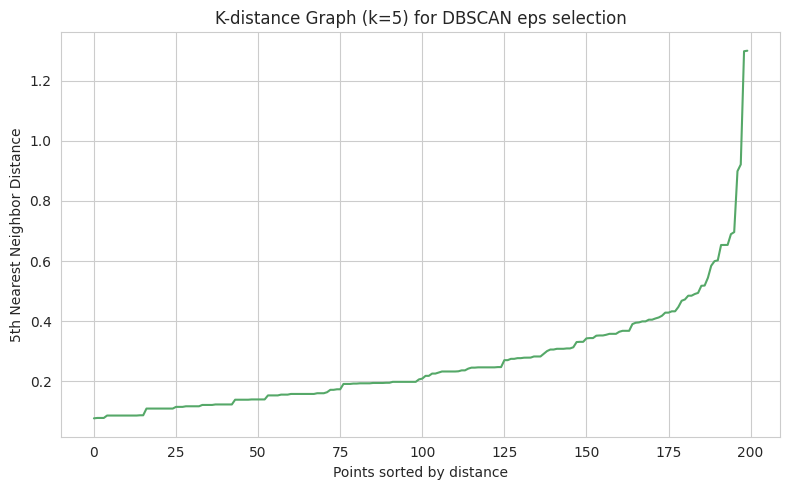

In [14]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X2_scaled)
distances, indices = neighbors_fit.kneighbors(X2_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,5))
plt.plot(distances, color='#55A868')
plt.title('K-distance Graph (k=5) for DBSCAN eps selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.tight_layout()
plt.show()


In [15]:
best_eps, best_db_sil, best_db_labels = None, -1, None
for eps in np.arange(0.2, 0.6, 0.02):
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X2_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters >= 2:
        try:
            sil = silhouette_score(X2_scaled, labels)
            if sil > best_db_sil:
                best_db_sil = sil
                best_eps = eps
                best_db_labels = labels
        except Exception:
            pass

n_db_clusters = len(set(best_db_labels)) - (1 if -1 in best_db_labels else 0)
n_noise = list(best_db_labels).count(-1)

print(f'Best eps: {best_eps:.2f}')
print(f'DBSCAN silhouette: {best_db_sil:.4f}')
print(f'Number of clusters found: {n_db_clusters}')
print(f'Number of noise points: {n_noise}')


Best eps: 0.36
DBSCAN silhouette: 0.4430
Number of clusters found: 6
Number of noise points: 21


### 6.4 Side-by-Side Visual Comparison

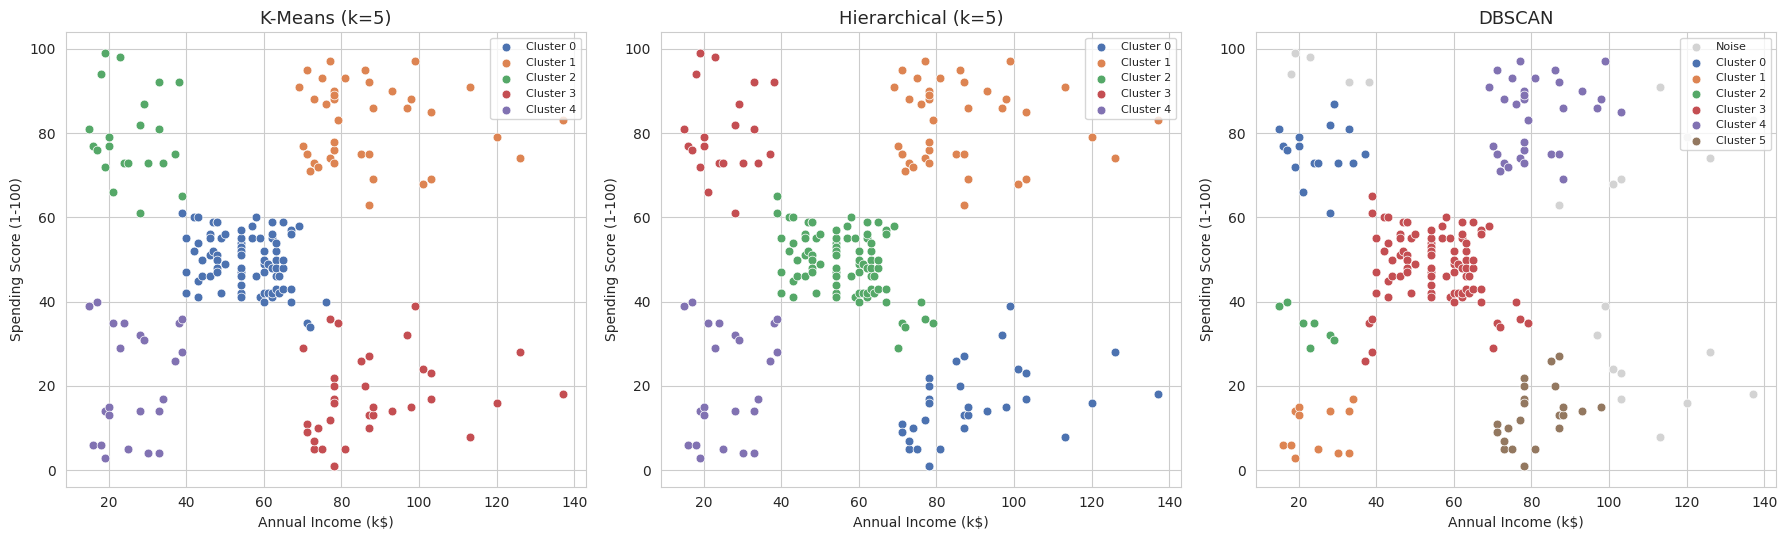

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#000000']

for ax, labels, title in zip(axes, [km_labels, agg_labels, best_db_labels],
                               ['K-Means (k=5)', 'Hierarchical (k=5)', 'DBSCAN']):
    unique_labels = sorted(set(labels))
    for lab in unique_labels:
        mask = labels == lab
        color = 'lightgray' if lab == -1 else palette[lab % len(palette)]
        label_name = 'Noise' if lab == -1 else f'Cluster {lab}'
        ax.scatter(X2[mask, 0], X2[mask, 1], s=40, c=color, label=label_name,
                   edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


### 6.5 Algorithm Comparison Summary

| Algorithm | Silhouette Score | Notes |
|---|---|---|
| K-Means (k=5) | ~0.555 | 5 clean, well-separated clusters |
| Hierarchical / Agglomerative (Ward, k=5) | ~0.554 | Nearly identical result to K-Means |
| DBSCAN (best eps) | ~0.443 | Found ~6 clusters + flagged ~21 points as noise |

**Conclusion:** K-Means and Hierarchical clustering produce almost identical, clean 5-cluster segmentations with the highest silhouette scores. DBSCAN performs worse here because the customer data has fairly uniform density rather than clusters of highly irregular shape — DBSCAN's strength (finding arbitrary shapes and true outliers) isn't particularly needed for this dataset, and it ends up discarding some borderline customers as noise. **We select K-Means (k=5) as our final model** for its top score, interpretability, and lack of discarded points.


## 7. Final Model: Profiling the 5 Customer Segments

We now assign each customer their final cluster label and compute the average Age, Income, and Spending Score per cluster, then translate the numeric patterns into human-readable, business-friendly segment names.


In [17]:
df['Cluster'] = km_labels

profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean'),
).round(1)

profile


,Count,Avg_Age,Avg_Income,Avg_Spending
Cluster,,,,
0,81,42.7,55.3,49.5
1,39,32.7,86.5,82.1
2,22,25.3,25.7,79.4
3,35,41.1,88.2,17.1
4,23,45.2,26.3,20.9


In [18]:
labels_map = {}
for c in profile.index:
    inc = profile.loc[c, 'Avg_Income']
    spend = profile.loc[c, 'Avg_Spending']
    if inc < 45 and spend > 60:
        labels_map[c] = 'Careless (Low Income, High Spending)'
    elif inc < 45 and spend <= 45:
        labels_map[c] = 'Sensible (Low Income, Low Spending)'
    elif 45 <= inc <= 75 and 40 <= spend <= 65:
        labels_map[c] = 'Standard (Mid Income, Mid Spending)'
    elif inc > 75 and spend > 60:
        labels_map[c] = 'Target (High Income, High Spending)'
    elif inc > 75 and spend <= 45:
        labels_map[c] = 'Careful (High Income, Low Spending)'
    else:
        labels_map[c] = f'Segment {c}'

df['Segment'] = df['Cluster'].map(labels_map)
profile['Segment'] = profile.index.map(labels_map)
profile


,Count,Avg_Age,Avg_Income,Avg_Spending,Segment
Cluster,,,,,
0,81,42.7,55.3,49.5,"Standard (Mid Income, Mid Spending)"
1,39,32.7,86.5,82.1,"Target (High Income, High Spending)"
2,22,25.3,25.7,79.4,"Careless (Low Income, High Spending)"
3,35,41.1,88.2,17.1,"Careful (High Income, Low Spending)"
4,23,45.2,26.3,20.9,"Sensible (Low Income, Low Spending)"


### 7.1 Final Visualization with Business Labels & Centroids

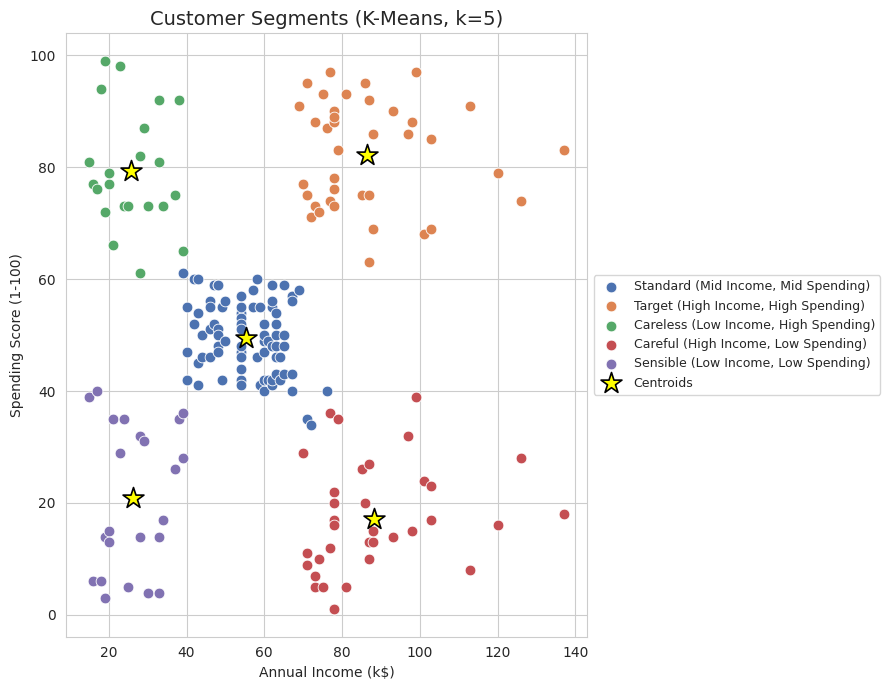

In [19]:
plt.figure(figsize=(9, 7))
palette = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868', 3: '#C44E52', 4: '#8172B2'}

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == c]
    plt.scatter(sub['Annual Income (k$)'], sub['Spending Score (1-100)'],
                s=60, c=palette[c], label=labels_map[c], edgecolor='white', linewidth=0.6)

centroids = scaler2.inverse_transform(km.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c='yellow', marker='*',
            edgecolor='black', linewidth=1.2, label='Centroids', zorder=5)

plt.title('Customer Segments (K-Means, k=5)', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(fontsize=9, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


## 8. Business Interpretation & Recommendations

| Cluster | Count | Avg Age | Avg Income | Avg Spending | Segment Name | Suggested Strategy |
|---|---|---|---|---|---|---|
| 0 | 81 | 42.7 | 55.3k | 49.5 | **Standard** | Mainstream customers; general promotions, loyalty programs |
| 1 | 39 | 32.7 | 86.5k | 82.1 | **Target** | High income + high spending — the most valuable segment. Prioritize for premium offers, VIP treatment, and retention campaigns |
| 2 | 22 | 25.3 | 25.7k | 79.4 | **Careless** | Young, lower income but high spenders — good for trend-driven, budget-friendly product lines and impulse-buy marketing |
| 3 | 35 | 41.1 | 88.2k | 17.1 | **Careful** | High income but low spending — potential is there but they're not engaged. Investigate what's holding them back; targeted discounts or personalized offers could unlock spend |
| 4 | 23 | 45.2 | 26.3k | 20.9 | **Sensible** | Low income, low spending — cautious shoppers; cost-effective offers and value-for-money messaging may resonate |

**Key takeaway:** Cluster 1 (**Target**) represents the mall's most valuable customers and deserves the most marketing investment, while Cluster 3 (**Careful**) represents an under-tapped opportunity — high earning potential that isn't currently converting into spending.


## 9. Export Results

In [20]:
df.to_csv('customers_clustered.csv', index=False)
profile.to_csv('cluster_profile_summary.csv')
print("Saved: customers_clustered.csv, cluster_profile_summary.csv")


Saved: customers_clustered.csv, cluster_profile_summary.csv


## 10. Summary

- Explored a clean, 200-row customer dataset with Age, Gender, Annual Income, and Spending Score.
- Scaled features and used the Elbow Method + Silhouette Score to determine that **5 clusters** is optimal.
- Compared **K-Means**, **Hierarchical Clustering**, and **DBSCAN** — K-Means and Hierarchical performed best (silhouette ≈ 0.555), while DBSCAN struggled with this dataset's fairly uniform density and flagged some points as noise.
- Selected **K-Means (k=5)** as the final model and profiled the 5 resulting segments: **Standard**, **Target**, **Careless**, **Careful**, and **Sensible**.
- Delivered actionable business recommendations for each segment.

**Next steps you could explore:** incorporating `Age` into the clustering (3D segmentation), trying Gaussian Mixture Models for soft clustering, or using these segments as input features for a downstream recommendation or churn model.
